In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LeakyReLU,ReLU,Softmax
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [30]:
df = pd.read_csv('earthquake_alert_balanced_dataset.csv')

In [31]:
df.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


In [32]:
x = df.iloc[:,0:-1]
y = np.array(df.iloc[:,-1]).reshape(-1,1)


In [33]:
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x,y_encoded,test_size=0.33,random_state=42)

In [36]:
SC = StandardScaler()

In [37]:
x_train = SC.fit_transform(x_train)
x_test = SC.fit_transform(x_test)

In [40]:
classifier = Sequential([
                        Dense(5,activation='relu'),
                        Dense(128,activation='relu'),
                        Dropout(0.3),
                        Dense(64,activation='relu'),
                        Dropout(0.2),
                        Dense(16,activation='relu'),
                        Dropout(0.1),
                        Dense(4,activation='softmax')])

In [41]:
earlystopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [42]:
classifier.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [43]:
history = classifier.fit(
    x_train, y_train,
    epochs=200,
    batch_size=10,
    validation_data=(x_test, y_test),
    verbose=1,
    callbacks = earlystopping
)

Epoch 1/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4466 - loss: 1.2082 - val_accuracy: 0.4988 - val_loss: 1.0783
Epoch 2/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4822 - loss: 1.0589 - val_accuracy: 0.5874 - val_loss: 0.9629
Epoch 3/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5499 - loss: 0.9830 - val_accuracy: 0.6340 - val_loss: 0.8844
Epoch 4/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5488 - loss: 0.9470 - val_accuracy: 0.6224 - val_loss: 0.8698
Epoch 5/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5798 - loss: 0.8987 - val_accuracy: 0.7063 - val_loss: 0.7801
Epoch 6/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6326 - loss: 0.8422 - val_accuracy: 0.7226 - val_loss: 0.7365
Epoch 7/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6521 - loss: 0.8117 - val_accuracy: 0.7133 - val_loss: 0.7190
Epoch 8/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6533 - loss: 0.7908 - val_accuracy: 0.7459 - 

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7704 - loss: 0.6039 - val_accuracy: 0.7809 - val_loss: 0.5750
Epoch 52/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7738 - loss: 0.5914 - val_accuracy: 0.7832 - val_loss: 0.5701
Epoch 53/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7750 - loss: 0.5874 - val_accuracy: 0.7716 - val_loss: 0.5657
Epoch 54/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7704 - loss: 0.6032 - val_accuracy: 0.7552 - val_loss: 0.5831
Epoch 55/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7577 - loss: 0.6050 - val_accuracy: 0.7762 - val_loss: 0.5637
Epoch 56/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7761 - loss: 0.5921 - val_accuracy: 0.7879 - val_loss: 0.5569
Epoch 57/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7773 - loss: 0.5918 - val_accuracy: 0.7855 - val_loss: 0.5601
Epoch 58/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7738 - loss: 0.5979 - val_accuracy: 0.7762 - val_lo

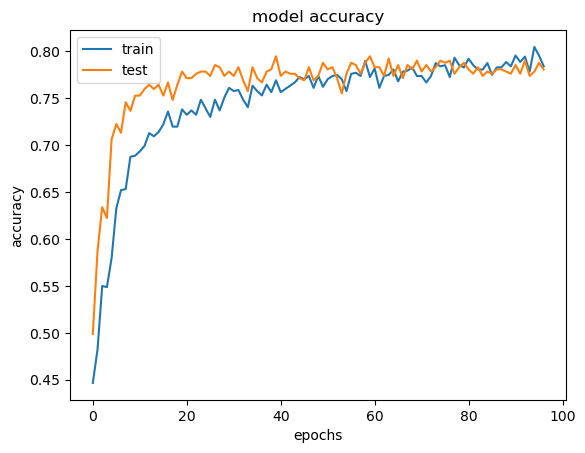

In [44]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train','test'],loc='upper left')

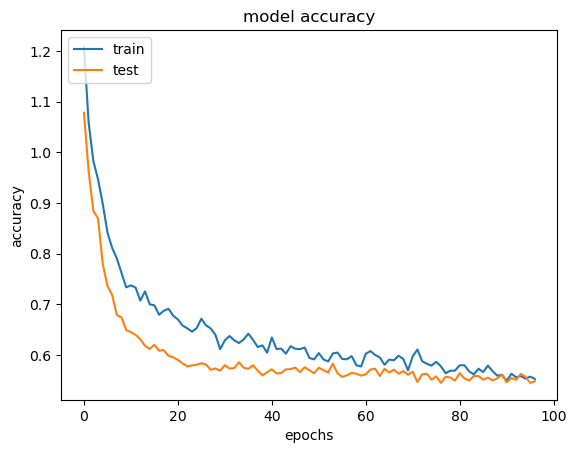

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train','test'],loc='upper left')

In [46]:
y_pred = classifier.predict(x_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [47]:
y_pred

array([[4.5395549e-03, 4.6566609e-01, 5.0692654e-01, 2.2867799e-02],
       [5.7150102e-03, 1.7294787e-01, 7.7039820e-01, 5.0938904e-02],
       [9.9999750e-01, 3.1331872e-35, 3.9744620e-20, 2.4575443e-06],
       ...,
       [5.2760843e-02, 7.1903586e-01, 2.4962532e-03, 2.2570708e-01],
       [9.9928600e-01, 2.1152321e-21, 2.9191656e-11, 7.1408151e-04],
       [1.2518635e-01, 9.7796309e-04, 4.3700695e-02, 8.3013511e-01]],
      dtype=float32)

In [48]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import seaborn as sns

In [49]:
y_pred_classes = y_pred.argmax(axis=1)   
y_true = y_test.argmax(axis=1)   

In [50]:
y_pred_classes

array([2, 2, 0, 1, 1, 3, 2, 1, 3, 3, 2, 3, 1, 1, 1, 1, 0, 1, 1, 3, 1, 3,
       3, 3, 2, 1, 1, 1, 1, 1, 3, 0, 3, 2, 1, 2, 2, 2, 1, 3, 1, 0, 0, 1,
       3, 0, 0, 1, 1, 2, 2, 3, 3, 0, 1, 2, 2, 0, 0, 3, 1, 0, 2, 0, 3, 2,
       1, 1, 1, 3, 1, 1, 0, 3, 2, 3, 0, 1, 2, 0, 0, 1, 2, 3, 1, 2, 0, 2,
       1, 1, 0, 3, 2, 3, 1, 3, 1, 2, 2, 3, 0, 1, 2, 2, 1, 1, 2, 3, 0, 1,
       3, 2, 1, 1, 0, 3, 2, 2, 3, 3, 3, 2, 0, 2, 1, 2, 2, 3, 3, 0, 3, 3,
       1, 0, 1, 1, 1, 3, 0, 3, 1, 2, 2, 1, 0, 1, 3, 2, 3, 3, 3, 2, 0, 0,
       3, 1, 3, 2, 3, 2, 3, 0, 2, 0, 2, 2, 1, 0, 0, 0, 2, 1, 1, 1, 2, 2,
       1, 3, 0, 0, 2, 3, 2, 3, 3, 1, 0, 2, 0, 2, 1, 1, 1, 2, 2, 0, 2, 1,
       2, 3, 0, 3, 0, 1, 1, 2, 2, 1, 3, 2, 3, 3, 0, 1, 2, 3, 2, 3, 3, 1,
       2, 1, 3, 1, 3, 1, 2, 0, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 0, 2, 0,
       1, 2, 1, 0, 1, 2, 0, 2, 0, 1, 1, 1, 2, 0, 3, 0, 0, 2, 2, 0, 0, 1,
       1, 0, 2, 2, 1, 3, 1, 0, 0, 0, 1, 2, 2, 0, 0, 3, 3, 1, 3, 2, 2, 3,
       0, 2, 3, 1, 0, 2, 2, 1, 0, 1, 1, 1, 3, 2, 2,

In [51]:
accuracy_score(y_true,y_pred_classes)

0.7808857808857809

<Axes: >

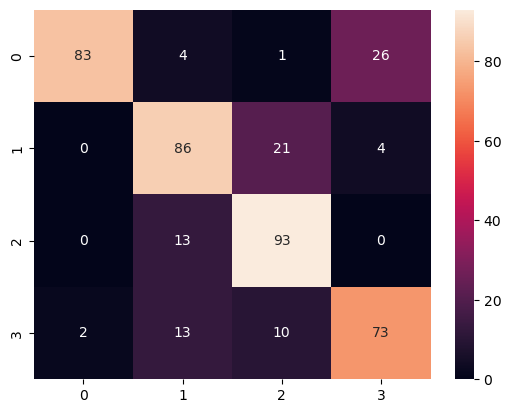

In [52]:
sns.heatmap(confusion_matrix(y_true,y_pred_classes),annot=True)

# DropOut Layer